In [1]:
import sys, os
sys.path.insert(0, '../../utils')

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from utils import load_neurons_table, load_synapses_position_transformed
from connectome_types import CONNECTOME_SYN_TABLE_PATH
from neuron_custom_features import calc_spines_features
from spines_utils import filter_valid_neuron_w_spines
from plot_utils import ex_color, inh_color
from figures_utils import plot_clf_type_triple_binned, add_panel_label
from matplotlib.ticker import FormatStrFormatter

In [3]:
neurons_df = load_neurons_table(use_column_manual_ct=True)
syn_df = load_synapses_position_transformed(base_syn_table_path=CONNECTOME_SYN_TABLE_PATH)
df, syn_with_tags = calc_spines_features(neurons_df, syn_df)
df, filtered_syn_mat, filtered_bin_mat, filtered_mapping, filtered_reverse_mapping, ex_neurons, inh_neurons = filter_valid_neuron_w_spines(df)

connectome neurons table:  1351
valid neurons w position: 1351
spine table incoming size (4567647, 4)
spine table outgoing size (819832, 4)
neurons: 1351
synapses with tags: 145356


100%|██████████| 1351/1351 [00:13<00:00, 100.48it/s]


Filtering neurons with valid spine data...
Remaining neurons after filtering: 1298
fixing networks
Filtering: Reducing matrix from 1351 to 1298 neurons.


In [4]:
plt.rcParams['font.size'] = 16
plt.rcParams['legend.fontsize'] = 13
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['font.family'] = 'Arial'

err_type = 'sem'
bin_amount_text_size = 12

main_x_feature = 'ds_spine_density'
x_label = 'Density of spinous synapses\n(syn/μm)'

[0.125, 0.375, 0.625, 0.875, 1.125, 1.375]
Sum of bin counts for E→E: 1139
Sum of bin counts for E→E: 1139
Sum of bin counts for E→E: 1139
[0.125, 0.375, 0.625, 0.875, 1.125, 1.375]
Sum of bin counts for E→I: 159
Sum of bin counts for E→I: 159
Sum of bin counts for E→I: 159


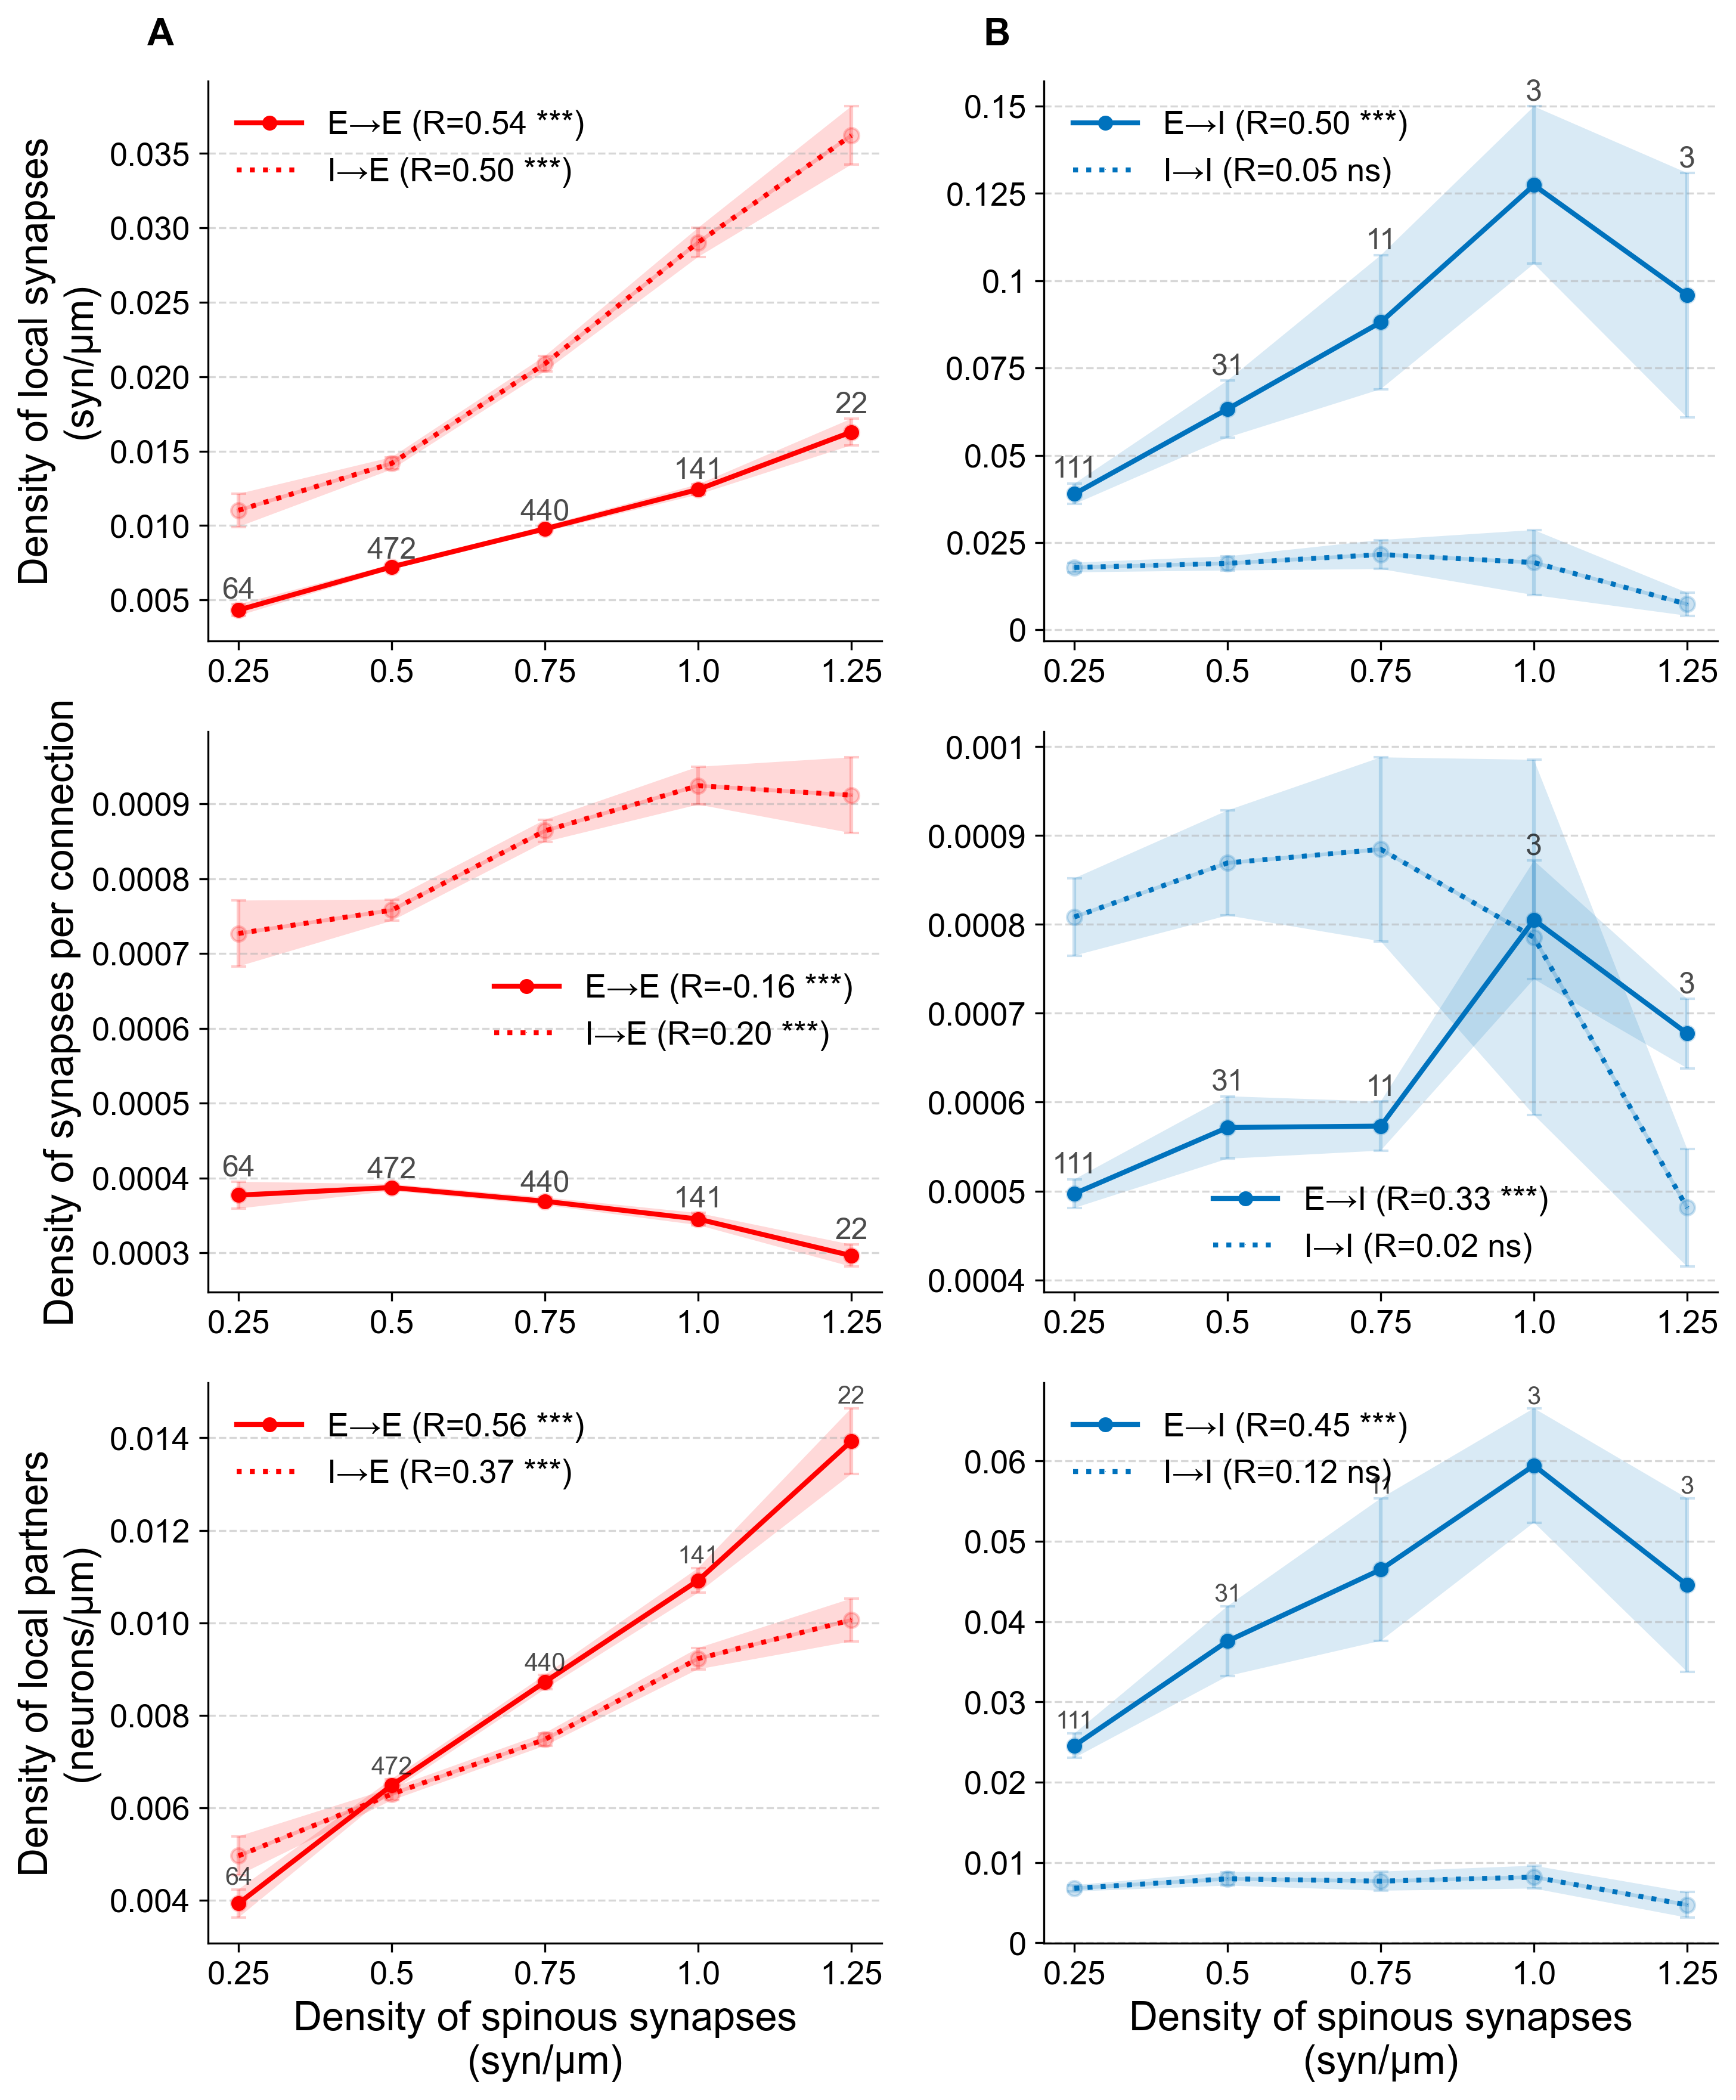

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12), dpi=300)

plot_clf_type_triple_binned(
    df=ex_neurons,
    names=['E\u2192E', 'I\u2192E'],
    colors=[ex_color, ex_color],
    x_axis=main_x_feature,
    x_label=x_label,
    ax_list=axes[:, 0],
    bin_amount_text_size=bin_amount_text_size,
    use_density=True
)

plot_clf_type_triple_binned(
    df=inh_neurons,
    names=['E\u2192I', 'I\u2192I'],
    colors=[inh_color, inh_color],
    x_axis=main_x_feature,
    x_label=x_label,
    ax_list=axes[:, 1],
    bin_amount_text_size=bin_amount_text_size,
    use_density=True
)
for ax in axes[:, 1]:
    ax.set_ylabel('')
    ax.yaxis.set_major_formatter(FormatStrFormatter('%g'))

add_panel_label(axes[0, 0], 'A', xy=(-0.05, 1.05), fontsize=15)
add_panel_label(axes[0, 1], 'B', xy=(-0.05, 1.05), fontsize=15)
plt.savefig('fig_s2.pdf', format='pdf', bbox_inches='tight')
fig.tight_layout()